# Fase de inferencia completa del recomendador HS30


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, f1_score
)

warnings.filterwarnings("ignore")

CANDIDATE_DIRS = [Path.cwd(), Path("/mnt/data")]

def find_file_any(filenames):
    if isinstance(filenames, str):
        filenames = [filenames]
    for filename in filenames:
        for d in CANDIDATE_DIRS:
            p = d / filename
            if p.exists():
                return p
    raise FileNotFoundError("No encuentro: " + ", ".join(filenames))

HOURLY_DATA_PATH = find_file_any("data_hourly_agg.csv")
DAILY_DATA_PATH = find_file_any("data_daily_agg.csv")
LEARNING_DATA_PATH = find_file_any("dataset_learning_24h.csv")

HS30_MODEL_PATH = find_file_any("modelo_indep_HS30_mean_seed_562.h5")
SCALER_PATH = find_file_any("scaler_params.pkl")

CLASSIFIER_PATH = find_file_any([
    "model_Hybrid_SMOTEplusCost_RF_final.pkl",
    "model_Hybrid_SMOTEplusCost_RF.pkl",
    "best_stress_classifier.pkl"
])

PEAK_MODEL_PATH = find_file_any("best_peak_model.joblib")

OUTPUT_DIR = Path.cwd() / "outputs_inferencia_final_comparable"
OUTPUT_DIR.mkdir(exist_ok=True)

TIME_COL_HOURLY = "instante"
TIME_COL_DAILY = "instante"
PAST_FEATURES = ["TA_mean", "HS10_mean", "HS30_mean"]
FUTURE_FEATURES = ["TA_mean"]
RADIATION_DAILY_COL = "radiacion_sum"
CLASSIFIER_FEATURES = ["radiacion_sum_t0", "HS30_min_t+1"]
FEATURE_TO_VARY = "HS30_min_t+1"
HS30_MAX = 1.0
DECISION_HOUR = 19

print("Archivos localizados correctamente")
print(HOURLY_DATA_PATH)
print(DAILY_DATA_PATH)
print(LEARNING_DATA_PATH)
print(HS30_MODEL_PATH)
print(SCALER_PATH)
print(CLASSIFIER_PATH)
print(PEAK_MODEL_PATH)

Archivos localizados correctamente
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\data_hourly_agg.csv
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\data_daily_agg.csv
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\dataset_learning_24h.csv
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\modelo_indep_HS30_mean_seed_562.h5
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\scaler_params.pkl
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\model_Hybrid_SMOTEplusCost_RF_final.pkl
c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\best_peak_model.joblib


## 1. Carga de datos y detección de columnas reales

In [3]:
hourly_df = pd.read_csv(HOURLY_DATA_PATH)
daily_df = pd.read_csv(DAILY_DATA_PATH)
learning_df = pd.read_csv(LEARNING_DATA_PATH)

hourly_df[TIME_COL_HOURLY] = pd.to_datetime(hourly_df[TIME_COL_HOURLY])
daily_df[TIME_COL_DAILY] = pd.to_datetime(daily_df[TIME_COL_DAILY])
learning_df["instante_t+1"] = pd.to_datetime(learning_df["instante_t+1"])

hourly_df = hourly_df.sort_values(TIME_COL_HOURLY).reset_index(drop=True)
daily_df = daily_df.sort_values(TIME_COL_DAILY).reset_index(drop=True)

hourly_df["date"] = hourly_df[TIME_COL_HOURLY].dt.date
daily_df["date"] = daily_df[TIME_COL_DAILY].dt.date
learning_df["date_t1"] = learning_df["instante_t+1"].dt.date

target_candidates = ["Target_Class"]
TARGET_COL = next((c for c in target_candidates if c in learning_df.columns), None)
if TARGET_COL is None:
    raise ValueError("No encuentro columna target en dataset_learning_24h.")

hs30_candidates = ["HS30_min_t+1", "HS30_min_t1", "HS30_min_next", "HS30_min"]
HS30_REAL_COL = next((c for c in hs30_candidates if c in learning_df.columns), None)
if HS30_REAL_COL is None:
    raise ValueError("No encuentro columna real de HS30_min_t+1 en dataset_learning_24h.")

for c in [TIME_COL_HOURLY] + PAST_FEATURES + FUTURE_FEATURES:
    if c not in hourly_df.columns:
        raise ValueError(f"Falta {c} en data_hourly_agg.csv")

if RADIATION_DAILY_COL not in daily_df.columns:
    raise ValueError(f"Falta {RADIATION_DAILY_COL} en data_daily_agg.csv")

print("Target:", TARGET_COL)
print("HS30 real:", HS30_REAL_COL)
print("Horario:", hourly_df.shape)
print("Diario:", daily_df.shape)
print("Learning:", learning_df.shape)
display(learning_df[["date_t1", TARGET_COL, HS30_REAL_COL]].head())

Target: Target_Class
HS30 real: HS30_min_t+1
Horario: (45457, 17)
Diario: (1895, 36)
Learning: (131, 39)


,date_t1,Target_Class,HS30_min_t+1
0,2018-08-12,0,0.803835
1,2018-08-19,0,0.797110
2,2018-08-26,0,0.807500
3,2018-08-29,0,0.806111
4,2018-09-02,0,0.804565


## 2. Carga de modelos, scaler y dimensiones del LSTM

In [4]:
clf_model = joblib.load(CLASSIFIER_PATH)
peak_model = joblib.load(PEAK_MODEL_PATH)
scaler_obj = joblib.load(SCALER_PATH)

def get_model_features(model, default=None):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "named_steps"):
        for step in model.named_steps.values():
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)
    return list(default) if default is not None else None

CLASSIFIER_FEATURES = get_model_features(clf_model, CLASSIFIER_FEATURES)
PEAK_FEATURES = get_model_features(peak_model, None)

try:
    import tensorflow as tf
    hs30_model = tf.keras.models.load_model(HS30_MODEL_PATH, compile=False)
except Exception as e:
    raise RuntimeError(f"No se ha podido cargar el modelo LSTM. Error: {repr(e)}")

input_shapes = [tuple(inp.shape) for inp in hs30_model.inputs]
PAST_HOURS = int(input_shapes[0][1])
N_PAST_FEATURES = int(input_shapes[0][2])
FUTURE_HOURS = int(input_shapes[1][1])
N_FUTURE_FEATURES = int(input_shapes[1][2])

print("Features clasificador:", CLASSIFIER_FEATURES)
print("Features peak:", PEAK_FEATURES)
print("Input shapes LSTM:", input_shapes)
print("PAST_HOURS:", PAST_HOURS, "FUTURE_HOURS:", FUTURE_HOURS)

if N_PAST_FEATURES != len(PAST_FEATURES):
    raise ValueError("El número de variables pasadas no coincide.")
if N_FUTURE_FEATURES != len(FUTURE_FEATURES):
    raise ValueError("El número de variables futuras no coincide.")

Features clasificador: ['radiacion_sum_t0', 'HS30_min_t+1']
Features peak: ['HS30_min_target', 'HS20_mean_hist_24h_max', 'HS30_mean_hist_48h_max', 'HS20_mean_hist_24h_min', 'HS10_mean_hist_48h_max']
Input shapes LSTM: [(None, 48, 3), (None, 24, 1)]
PAST_HOURS: 48 FUTURE_HOURS: 24


## 3. Escalado del LSTM

In [5]:
SCALER_FEATURES_DEFAULT = ["TA_mean", "HS10_mean", "HS30_mean", "HS60_mean"]

if hasattr(scaler_obj, "feature_names_in_"):
    SCALER_FEATURES = list(scaler_obj.feature_names_in_)
else:
    SCALER_FEATURES = SCALER_FEATURES_DEFAULT

print("Variables del scaler:", SCALER_FEATURES)

if "HS30_mean" not in SCALER_FEATURES:
    raise ValueError("El scaler no contiene HS30_mean.")

def scaler_params_for(feature):
    idx = SCALER_FEATURES.index(feature)
    if hasattr(scaler_obj, "mean_") and hasattr(scaler_obj, "scale_"):
        return float(scaler_obj.mean_[idx]), float(scaler_obj.scale_[idx]), "standard"
    if hasattr(scaler_obj, "data_min_") and hasattr(scaler_obj, "data_max_"):
        return float(scaler_obj.data_min_[idx]), float(scaler_obj.data_max_[idx]), "minmax"
    raise ValueError("Tipo de scaler no reconocido.")

def scale_feature(values, feature):
    a, b, typ = scaler_params_for(feature)
    values = np.asarray(values, dtype=float)
    if typ == "standard":
        return (values - a) / b
    if typ == "minmax":
        return (values - a) / (b - a)
    raise ValueError(typ)

def inverse_scale_feature(values_scaled, feature):
    a, b, typ = scaler_params_for(feature)
    values_scaled = np.asarray(values_scaled, dtype=float)
    if typ == "standard":
        return values_scaled * b + a
    if typ == "minmax":
        return values_scaled * (b - a) + a
    raise ValueError(typ)

print("Parámetros HS30_mean:", scaler_params_for("HS30_mean"))

Variables del scaler: ['TA_mean', 'HS10_mean', 'HS30_mean', 'HS60_mean']
Parámetros HS30_mean: (0.7712527688624473, 0.042382551037717174, 'standard')


## 4. Selección de instantes comparables

In [6]:
def available_decision_times(hourly_df, daily_df):
    times = hourly_df[TIME_COL_HOURLY]
    candidate_times = hourly_df.loc[
        (times.dt.hour == DECISION_HOUR) & (times.dt.minute == 0),
        TIME_COL_HOURLY
    ].drop_duplicates().sort_values()

    valid = []
    time_set = set(times)
    daily_dates = set(daily_df["date"])

    for t in candidate_times:
        past_start = t - pd.Timedelta(hours=PAST_HOURS - 1)
        future_end = t + pd.Timedelta(hours=FUTURE_HOURS)

        past_range = pd.date_range(past_start, t, freq="h")
        future_range = pd.date_range(t + pd.Timedelta(hours=1), future_end, freq="h")

        if all(x in time_set for x in past_range) and all(x in time_set for x in future_range) and t.date() in daily_dates:
            valid.append(t)

    return pd.Series(valid, name="inference_datetime")

valid_times_all = available_decision_times(hourly_df, daily_df)

valid_learning_dates_t1 = set(learning_df["date_t1"].dropna())
valid_times = pd.Series([
    t for t in valid_times_all
    if (pd.Timestamp(t) + pd.Timedelta(days=1)).date() in valid_learning_dates_t1
], name="inference_datetime")

print("Momentos válidos por ventanas LSTM:", len(valid_times_all))
print("Momentos comparables con dataset_learning_24h:", len(valid_times))
display(valid_times.head())

if len(valid_times) == 0:
    raise ValueError("No hay momentos válidos comparables.")

Momentos válidos por ventanas LSTM: 1891
Momentos comparables con dataset_learning_24h: 128


0   2018-08-11 19:00:00
1   2018-08-18 19:00:00
2   2018-08-25 19:00:00
3   2018-08-28 19:00:00
4   2018-09-01 19:00:00
Name: inference_datetime, dtype: datetime64[ns]

## 5. Funciones del pipeline

In [7]:
def build_lstm_inputs(hourly_df, inference_datetime):
    t = pd.Timestamp(inference_datetime)
    past_start = t - pd.Timedelta(hours=PAST_HOURS - 1)
    past_end = t
    future_start = t + pd.Timedelta(hours=1)
    future_end = t + pd.Timedelta(hours=FUTURE_HOURS)

    past = hourly_df[(hourly_df[TIME_COL_HOURLY] >= past_start) & (hourly_df[TIME_COL_HOURLY] <= past_end)].copy()
    future = hourly_df[(hourly_df[TIME_COL_HOURLY] >= future_start) & (hourly_df[TIME_COL_HOURLY] <= future_end)].copy()

    past = past.set_index(TIME_COL_HOURLY).reindex(pd.date_range(past_start, past_end, freq="h"))
    future = future.set_index(TIME_COL_HOURLY).reindex(pd.date_range(future_start, future_end, freq="h"))

    if past[PAST_FEATURES].isna().any().any():
        raise ValueError(f"NaN en ventana histórica: {t}")
    if future[FUTURE_FEATURES].isna().any().any():
        raise ValueError(f"NaN en ventana futura: {t}")

    past_scaled = past[PAST_FEATURES].copy()
    for col in PAST_FEATURES:
        past_scaled[col] = scale_feature(past_scaled[col].values, col)

    future_scaled = future[FUTURE_FEATURES].copy()
    for col in FUTURE_FEATURES:
        future_scaled[col] = scale_feature(future_scaled[col].values, col)

    X_past = past_scaled[PAST_FEATURES].to_numpy(float).reshape(1, PAST_HOURS, len(PAST_FEATURES))
    X_future = future_scaled[FUTURE_FEATURES].to_numpy(float).reshape(1, FUTURE_HOURS, len(FUTURE_FEATURES))

    return [X_past, X_future], past.reset_index(names=TIME_COL_HOURLY), future.reset_index(names=TIME_COL_HOURLY)

def get_daily_context(daily_df, inference_datetime):
    t = pd.Timestamp(inference_datetime)
    row = daily_df[daily_df["date"] == t.date()]
    if row.empty:
        raise ValueError(f"No hay dato diario para {t.date()}")
    return {
        "date_t": t.date(),
        "date_t1": (t + pd.Timedelta(days=1)).date(),
        "radiacion_sum_t0": float(row[RADIATION_DAILY_COL].iloc[0]),
        "radiation_source": "daily_full_or_forecast"
    }

def build_peak_context(hourly_df, inference_datetime):
    t = pd.Timestamp(inference_datetime)
    hist_24h = hourly_df[(hourly_df[TIME_COL_HOURLY] > t - pd.Timedelta(hours=24)) & (hourly_df[TIME_COL_HOURLY] <= t)].copy()
    hist_48h = hourly_df[(hourly_df[TIME_COL_HOURLY] > t - pd.Timedelta(hours=48)) & (hourly_df[TIME_COL_HOURLY] <= t)].copy()
    future_24h = hourly_df[(hourly_df[TIME_COL_HOURLY] > t) & (hourly_df[TIME_COL_HOURLY] <= t + pd.Timedelta(hours=24))].copy()

    if len(hist_24h) < 20 or len(hist_48h) < 44 or len(future_24h) < 20:
        raise ValueError(f"Ventanas incompletas para peak: {t}")

    context = {}
    base_features = ["TA_mean", "HA_mean", "radiacion_mean", "HS10_mean", "HS20_mean", "HS30_mean", "TS30_mean", "litros_intervalo_sum"]
    base_features = [c for c in base_features if c in hourly_df.columns]

    for feature in base_features:
        for label, window_df in [("24h", hist_24h), ("48h", hist_48h)]:
            context[f"{feature}_hist_{label}_mean"] = float(window_df[feature].mean())
            context[f"{feature}_hist_{label}_min"] = float(window_df[feature].min())
            context[f"{feature}_hist_{label}_max"] = float(window_df[feature].max())
            context[f"{feature}_hist_{label}_std"] = float(window_df[feature].std())

    if "TA_mean" in hourly_df.columns:
        context["TA_mean_future_24h_mean"] = float(future_24h["TA_mean"].mean())
        context["TA_mean_future_24h_min"] = float(future_24h["TA_mean"].min())
        context["TA_mean_future_24h_max"] = float(future_24h["TA_mean"].max())
        context["TA_mean_future_24h_std"] = float(future_24h["TA_mean"].std())

    return context, hist_24h, hist_48h, future_24h

def extract_hs30_from_lstm_output(y_pred):
    y_pred = np.asarray(y_pred)
    if y_pred.ndim == 3:
        return y_pred[0, :, 1] if y_pred.shape[-1] >= 3 else y_pred[0, :, 0]
    if y_pred.ndim == 2:
        return y_pred[0, :]
    if y_pred.ndim == 1:
        return y_pred
    raise ValueError(f"Formato de salida no reconocido: {y_pred.shape}")

def predict_hs30_tomorrow(hs30_model, X_lstm):
    y_scaled_raw = hs30_model.predict(X_lstm, verbose=0)
    y_scaled = extract_hs30_from_lstm_output(y_scaled_raw)
    y_real = inverse_scale_feature(y_scaled, "HS30_mean")
    return float(np.min(y_real)), float(np.mean(y_real)), pd.DataFrame({
        "horizon_hour": np.arange(1, len(y_real) + 1),
        "HS30_pred_scaled": y_scaled,
        "HS30_pred": y_real
    })

def classify_stress(clf_model, daily_context, hs30_min_t1):
    row = {"radiacion_sum_t0": float(daily_context["radiacion_sum_t0"]), "HS30_min_t+1": float(hs30_min_t1)}
    missing = [c for c in CLASSIFIER_FEATURES if c not in row]
    if missing:
        raise ValueError(f"Faltan variables para clasificador: {missing}")
    x_clf = pd.DataFrame([{c: row[c] for c in CLASSIFIER_FEATURES}])
    pred = int(clf_model.predict(x_clf)[0])
    prob = float(clf_model.predict_proba(x_clf)[0, 1]) if hasattr(clf_model, "predict_proba") else np.nan
    return pred, prob, x_clf

def predict_required_peak(peak_model, peak_context, hs30_min_target):
    row = dict(peak_context)
    row["HS30_min_target"] = float(hs30_min_target)
    features = PEAK_FEATURES or ["HS30_min_target", "HS20_mean_hist_24h_max", "HS30_mean_hist_48h_max", "HS20_mean_hist_24h_min", "HS10_mean_hist_48h_max"]
    missing = [c for c in features if c not in row]
    if missing:
        raise ValueError("Faltan variables para peak: " + str(missing))
    x_peak = pd.DataFrame([{c: row[c] for c in features}])
    required_peak = float(peak_model.predict(x_peak)[0])
    return required_peak, required_peak - float(hs30_min_target), x_peak

## 6. Ejecutar inferencia sobre casos comparables

In [8]:
def evaluate_candidate(inference_datetime):
    X_lstm, _, _ = build_lstm_inputs(hourly_df, inference_datetime)
    daily_context = get_daily_context(daily_df, inference_datetime)
    hs30_min_t1, hs30_mean_t1, _ = predict_hs30_tomorrow(hs30_model, X_lstm)
    stress_pred, stress_prob, _ = classify_stress(clf_model, daily_context, hs30_min_t1)
    return {
        "inference_datetime": pd.Timestamp(inference_datetime),
        "date_t": daily_context["date_t"],
        "date_t1": daily_context["date_t1"],
        "radiacion_sum_t0": daily_context["radiacion_sum_t0"],
        "radiation_source": daily_context["radiation_source"],
        "HS30_min_t+1_pred": hs30_min_t1,
        "HS30_mean_t+1_pred": hs30_mean_t1,
        "stress_t+1_pred": stress_pred,
        "stress_t+1_prob": stress_prob
    }

candidate_rows, errors = [], []
for t in valid_times:
    try:
        candidate_rows.append(evaluate_candidate(t))
    except Exception as e:
        errors.append({"inference_datetime": t, "error": repr(e)})

candidate_results_df = pd.DataFrame(candidate_rows)
errors_df = pd.DataFrame(errors)

print("Candidatos comparables intentados:", len(valid_times))
print("Candidatos evaluados correctamente:", len(candidate_results_df))
print("Errores:", len(errors_df))

if not errors_df.empty:
    display(errors_df.head(10))

if candidate_results_df.empty:
    raise ValueError("No se evaluó ningún candidato comparable.")

labels_df = learning_df[["date_t1", TARGET_COL, HS30_REAL_COL]].rename(columns={
    TARGET_COL: "stress_real",
    HS30_REAL_COL: "HS30_min_t+1_real"
}).drop_duplicates(subset=["date_t1"])

candidate_results_df = candidate_results_df.merge(labels_df, on="date_t1", how="left")

print("NaN stress_real:", candidate_results_df["stress_real"].isna().sum())
print("NaN HS30 real:", candidate_results_df["HS30_min_t+1_real"].isna().sum())
display(candidate_results_df.head())

Candidatos comparables intentados: 128
Candidatos evaluados correctamente: 97
Errores: 31


,inference_datetime,error
0,2018-09-08 19:00:00,ValueError('NaN en ventana histórica: 2018-09-...
1,2018-09-30 19:00:00,ValueError('NaN en ventana histórica: 2018-09-...
2,2018-10-23 19:00:00,ValueError('NaN en ventana histórica: 2018-10-...
3,2018-10-24 19:00:00,ValueError('NaN en ventana histórica: 2018-10-...
4,2020-05-23 19:00:00,ValueError('NaN en ventana histórica: 2020-05-...
5,2020-06-01 19:00:00,ValueError('NaN en ventana histórica: 2020-06-...
6,2020-06-03 19:00:00,ValueError('NaN en ventana histórica: 2020-06-...
7,2020-06-05 19:00:00,ValueError('NaN en ventana histórica: 2020-06-...
8,2020-06-07 19:00:00,ValueError('NaN en ventana histórica: 2020-06-...
9,2020-06-12 19:00:00,ValueError('NaN en ventana histórica: 2020-06-...


NaN stress_real: 0
NaN HS30 real: 0


,inference_datetime,date_t,date_t1,radiacion_sum_t0,radiation_source,HS30_min_t+1_pred,HS30_mean_t+1_pred,stress_t+1_pred,stress_t+1_prob,stress_real,HS30_min_t+1_real
0,2018-08-11 19:00:00,2018-08-11,2018-08-12,35197.35,daily_full_or_forecast,0.804468,0.815676,0,0.137441,0,0.803835
1,2018-08-18 19:00:00,2018-08-18,2018-08-19,27113.85,daily_full_or_forecast,0.804372,0.813510,0,0.137441,0,0.797110
2,2018-08-25 19:00:00,2018-08-25,2018-08-26,36171.60,daily_full_or_forecast,0.807595,0.816420,0,0.137441,0,0.807500
3,2018-08-28 19:00:00,2018-08-28,2018-08-29,29817.18,daily_full_or_forecast,0.805313,0.817604,0,0.137441,0,0.806111
4,2018-09-01 19:00:00,2018-09-01,2018-09-02,35289.36,daily_full_or_forecast,0.805579,0.815845,0,0.137441,0,0.804565


## 7. DiCE y modelo de peak post-riego

In [11]:
# %% [markdown]
# ## 9. DiCE real y modelo de peak post-riego

# %%
import dice_ml
from dice_ml import Dice

# =========================
# PREPARAR DICE
# =========================

FEATURES = ["radiacion_sum_t0", "HS30_min_t+1"]
FEATURES_TO_VARY_DICE = ["HS30_min_t+1"]
HS30_MAX = 1.0

dice_train_df = learning_df[FEATURES + [TARGET_COL]].dropna().copy()
dice_train_df = dice_train_df.rename(columns={TARGET_COL: "stress"})

d = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=FEATURES,
    outcome_name="stress"
)

m = dice_ml.Model(
    model=clf_model,
    backend="sklearn"
)

exp = Dice(d, m, method="random")

print("DiCE preparado correctamente.")
display(dice_train_df.head())

DiCE preparado correctamente.


,radiacion_sum_t0,HS30_min_t+1,stress
0,6006.0,0.803835,0
1,4792.0,0.797110,0
2,6235.0,0.807500,0
3,4594.0,0.806111,0
4,6304.0,0.804565,0


In [ ]:
# =========================
# CREAR CASOS DE ESTRÉS CON HS30 PREDICHO
# =========================

stress_cases = candidate_results_df[
    candidate_results_df["stress_t+1_pred"] == 1
].copy()

# Importante:
# Para DiCE usamos la misma variable del entrenamiento,
# pero sustituyendo el valor real por el predicho por el LSTM.
stress_cases["HS30_min_t+1"] = stress_cases["HS30_min_t+1_pred"]

stress_cases = stress_cases[[
    "radiacion_sum_t0",
    "HS30_min_t+1",
    "inference_datetime",
    "date_t",
    "date_t1",
    "stress_t+1_prob",
    "stress_real",
    "HS30_min_t+1_real"
]].copy()

stress_cases = stress_cases.rename(
    columns={"stress_t+1_prob": "pred_prob_stress"}
)

print("Casos de estrés detectados para DiCE:", len(stress_cases))
display(stress_cases.head())

Casos de estrés detectados para DiCE: 36


,radiacion_sum_t0,HS30_min_t+1,inference_datetime,date_t,date_t1,pred_prob_stress,stress_real,HS30_min_t+1_real
35,36291.72,0.732537,2019-08-31 19:00:00,2019-08-31,2019-09-01,0.538056,0,0.739204
36,2497.38,0.769045,2019-09-12 19:00:00,2019-09-12,2019-09-13,0.927980,1,0.767013
38,12162.00,0.735872,2019-09-14 19:00:00,2019-09-14,2019-09-15,0.538056,1,0.735565
39,32983.05,0.723327,2019-09-15 19:00:00,2019-09-15,2019-09-16,0.530525,0,0.723176
40,35577.51,0.712330,2019-09-16 19:00:00,2019-09-16,2019-09-17,0.509453,0,0.718594


In [ ]:
# =========================
# GENERAR 1 CONTRAFACTUAL POR CASO CON DICE
# =========================

all_cf_rows = []
cases_without_cf = []
cases_with_errors = []

for i in range(len(stress_cases)):
    query_instance = stress_cases[FEATURES].iloc[[i]].copy()

    real_hs30 = query_instance["HS30_min_t+1"].iloc[0]
    lower_bound = min(real_hs30 + 0.001, HS30_MAX)

    if lower_bound >= HS30_MAX:
        cases_without_cf.append(i)
        continue

    try:
        dice_exp = exp.generate_counterfactuals(
            query_instance,
            total_CFs=1,
            desired_class=0,
            features_to_vary=FEATURES_TO_VARY_DICE,
            permitted_range={"HS30_min_t+1": [lower_bound, HS30_MAX]}
        )

        cf_df = dice_exp.cf_examples_list[0].final_cfs_df

        if cf_df is None or cf_df.empty:
            cases_without_cf.append(i)
            continue

        cf_df = cf_df.copy()
        cf_df["case_index"] = i

        for col in FEATURES:
            cf_df[f"original_{col}"] = query_instance.iloc[0][col]

        for meta_col in [
            "inference_datetime",
            "date_t",
            "date_t1",
            "stress_real",
            "HS30_min_t+1_real",
            "pred_prob_stress"
        ]:
            if meta_col in stress_cases.columns:
                cf_df[meta_col] = stress_cases.iloc[i][meta_col]

        cf_hs30 = cf_df["HS30_min_t+1"].iloc[0]

        if (cf_hs30 > real_hs30) and (cf_hs30 <= HS30_MAX):
            cf_df["delta_HS30_min_t+1"] = cf_hs30 - real_hs30

            if hasattr(clf_model, "predict_proba"):
                cf_df["cf_prob_stress"] = clf_model.predict_proba(cf_df[FEATURES])[:, 1]
            else:
                cf_df["cf_prob_stress"] = np.nan

            cf_df["cf_pred_stress"] = clf_model.predict(cf_df[FEATURES])

            all_cf_rows.append(cf_df)
        else:
            cases_without_cf.append(i)

    except Exception as e:
        cases_without_cf.append(i)
        cases_with_errors.append({
            "case_index": i,
            "error": str(e)
        })
        continue

cf_results = pd.concat(all_cf_rows, ignore_index=True) if all_cf_rows else pd.DataFrame()
cases_without_cf_df = pd.DataFrame({"case_index": cases_without_cf})
cases_with_errors_df = pd.DataFrame(cases_with_errors)

print("=== RESUMEN DICE ===")
print("Casos de estrés detectados:", len(stress_cases))
print("Casos con contrafactual:", len(cf_results))
print("Casos sin contrafactual:", len(cases_without_cf))
print("Casos con error controlado:", len(cases_with_errors))

display(cf_results.head())

if not cases_with_errors_df.empty:
    display(cases_with_errors_df.head())

100%|██████████| 1/1 [00:00<00:00, 47.21it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 20.78it/s]

=== RESUMEN DICE ===
Casos de estrés detectados: 36
Casos con contrafactual: 35
Casos sin contrafactual: 1
Casos con error controlado: 1


,radiacion_sum_t0,HS30_min_t+1,stress,case_index,original_radiacion_sum_t0,original_HS30_min_t+1,inference_datetime,date_t,date_t1,stress_real,HS30_min_t+1_real,pred_prob_stress,delta_HS30_min_t+1,cf_prob_stress,cf_pred_stress
0,36291.72,0.916939,0,0,36291.72,0.732537,2019-08-31 19:00:00,2019-08-31,2019-09-01,0,0.739204,0.538056,0.184402,0.07518,0
1,12162.00,0.842491,0,2,12162.00,0.735872,2019-09-14 19:00:00,2019-09-14,2019-09-15,1,0.735565,0.538056,0.106619,0.07518,0
2,32983.05,0.832096,0,3,32983.05,0.723327,2019-09-15 19:00:00,2019-09-15,2019-09-16,0,0.723176,0.530525,0.108769,0.07518,0
3,35577.51,0.843743,0,4,35577.51,0.712330,2019-09-16 19:00:00,2019-09-16,2019-09-17,0,0.718594,0.509453,0.131414,0.07518,0
4,20648.10,0.817128,0,5,20648.10,0.710581,2019-09-17 19:00:00,2019-09-17,2019-09-18,1,0.711295,0.509453,0.106548,0.07518,0


,case_index,error
0,1,No counterfactuals found for any of the query ...


In [ ]:
# =========================
# APLICAR MODELO PEAK A LOS CONTRAFACTUALES
# =========================

PEAK_FINAL_FEATURES = [
    "HS30_min_target",
    "HS20_mean_hist_24h_max",
    "HS30_mean_hist_48h_max",
    "HS20_mean_hist_24h_min",
    "HS10_mean_hist_48h_max"
]

print("Features usadas por el modelo peak:")
print(PEAK_FINAL_FEATURES)

# Extraemos SOLO el regresor para evitar el error del SimpleImputer
peak_regressor = peak_model.named_steps["model"]


# =========================
# FUNCIÓN PREDICCIÓN PEAK
# =========================

def predict_required_peak(peak_model, peak_context, hs30_min_target):

    row = {}

    # Variable objetivo del recomendador
    row["HS30_min_target"] = float(hs30_min_target)

    # Añadimos las variables necesarias
    for feature in PEAK_FINAL_FEATURES:

        if feature == "HS30_min_target":
            continue

        if feature not in peak_context:
            raise ValueError(f"Falta {feature} en peak_context")

        row[feature] = peak_context[feature]

    # Construcción EXACTA del dataframe
    x_peak = pd.DataFrame([row])[PEAK_FINAL_FEATURES]

    # Predicción usando SOLO el modelo interno
    required_peak = float(
        peak_regressor.predict(x_peak)[0]
    )

    estimated_amplitude = (
        required_peak - float(hs30_min_target)
    )

    return required_peak, estimated_amplitude, x_peak


# =========================
# EJECUTAR SOBRE CONTRAFACTUALES
# =========================

peak_rows = []
peak_errors = []

for _, row in cf_results.iterrows():

    try:

        inference_datetime = row["inference_datetime"]

        peak_context, hist_24h, hist_48h, future_peak_24h = build_peak_context(
            hourly_df,
            inference_datetime
        )

        required_peak, estimated_amplitude, x_peak = predict_required_peak(
            peak_model,
            peak_context,
            row["HS30_min_t+1"]
        )

        out = row.to_dict()

        out["hs30_min_target"] = row["HS30_min_t+1"]

        out["required_peak"] = required_peak

        out["estimated_amplitude"] = estimated_amplitude

        peak_rows.append(out)

    except Exception as e:

        peak_errors.append({
            "inference_datetime": row.get("inference_datetime", None),
            "error": str(e)
        })


cf_peak_results = pd.DataFrame(peak_rows)

peak_errors_df = pd.DataFrame(peak_errors)

print("Contrafactuales con peak calculado:", len(cf_peak_results))
print("Errores en peak:", len(peak_errors_df))

display(cf_peak_results.head())

if not peak_errors_df.empty:
    display(peak_errors_df.head())

Features usadas por el modelo peak:
['HS30_min_target', 'HS20_mean_hist_24h_max', 'HS30_mean_hist_48h_max', 'HS20_mean_hist_24h_min', 'HS10_mean_hist_48h_max']
Contrafactuales con peak calculado: 35
Errores en peak: 0


,radiacion_sum_t0,HS30_min_t+1,stress,case_index,original_radiacion_sum_t0,original_HS30_min_t+1,inference_datetime,date_t,date_t1,stress_real,HS30_min_t+1_real,pred_prob_stress,delta_HS30_min_t+1,cf_prob_stress,cf_pred_stress,hs30_min_target,required_peak,estimated_amplitude
0,36291.72,0.916939,0,0,36291.72,0.732537,2019-08-31 19:00:00,2019-08-31,2019-09-01,0,0.739204,0.538056,0.184402,0.07518,0,0.916939,0.822390,-0.094550
1,12162.00,0.842491,0,2,12162.00,0.735872,2019-09-14 19:00:00,2019-09-14,2019-09-15,1,0.735565,0.538056,0.106619,0.07518,0,0.842491,0.806687,-0.035804
2,32983.05,0.832096,0,3,32983.05,0.723327,2019-09-15 19:00:00,2019-09-15,2019-09-16,0,0.723176,0.530525,0.108769,0.07518,0,0.832096,0.799231,-0.032864
3,35577.51,0.843743,0,4,35577.51,0.712330,2019-09-16 19:00:00,2019-09-16,2019-09-17,0,0.718594,0.509453,0.131414,0.07518,0,0.843743,0.800665,-0.043078
4,20648.10,0.817128,0,5,20648.10,0.710581,2019-09-17 19:00:00,2019-09-17,2019-09-18,1,0.711295,0.509453,0.106548,0.07518,0,0.817128,0.802866,-0.014262


## 8. Caso representativo

Casos con contrafactual válido y peak calculado: 35


,radiacion_sum_t0,HS30_min_t+1,stress,case_index,original_radiacion_sum_t0,original_HS30_min_t+1,inference_datetime,date_t,date_t1,stress_real,HS30_min_t+1_real,pred_prob_stress,delta_HS30_min_t+1,cf_prob_stress,cf_pred_stress,hs30_min_target,required_peak,estimated_amplitude
18,25089.03,0.737493,0,19,25089.03,0.698063,2021-09-22 19:00:00,2021-09-22,2021-09-23,1,0.691907,0.688620,0.039429,0.478464,0,0.737493,0.776504,0.039012
27,19050.87,0.983167,0,28,19050.87,0.692565,2022-10-06 19:00:00,2022-10-06,2022-10-07,1,0.686896,0.688620,0.290602,0.075180,0,0.983167,0.803326,-0.179841
22,23893.83,0.990243,0,23,23893.83,0.690265,2021-10-11 19:00:00,2021-10-11,2021-10-12,0,0.683108,0.669335,0.299978,0.075180,0,0.990243,0.807970,-0.182273
26,25382.58,0.962351,0,27,25382.58,0.700530,2022-09-26 19:00:00,2022-09-26,2022-09-27,1,0.694932,0.576740,0.261821,0.075180,0,0.962351,0.802946,-0.159404
13,39404.25,0.942736,0,14,39404.25,0.702310,2021-08-28 19:00:00,2021-08-28,2021-08-29,0,0.700522,0.550586,0.240425,0.075180,0,0.942736,0.809138,-0.133598


,radiacion_sum_t0,HS30_min_t+1,stress,case_index,original_radiacion_sum_t0,original_HS30_min_t+1,inference_datetime,date_t,date_t1,stress_real,HS30_min_t+1_real,pred_prob_stress,delta_HS30_min_t+1,cf_prob_stress,cf_pred_stress,hs30_min_target,required_peak,estimated_amplitude
18,25089.03,0.737493,0,19,25089.03,0.698063,2021-09-22 19:00:00,2021-09-22,2021-09-23,1,0.691907,0.68862,0.039429,0.478464,0,0.737493,0.776504,0.039012


,horizon_hour,HS30_pred_scaled,HS30_pred
0,1,-1.235409,0.718893
1,2,-1.254082,0.718102
2,3,-1.266109,0.717592
3,4,-1.273360,0.717285
4,5,-1.279710,0.717015


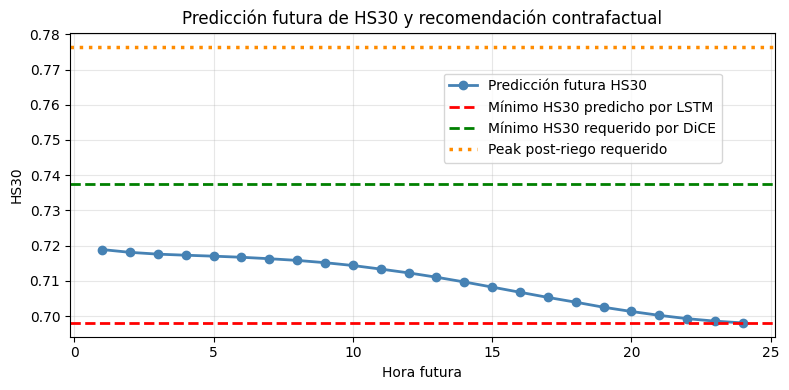

In [ ]:
cf_peak_stress_cases = cf_peak_results.copy()

# Asegurar que existe pred_prob_stress
cf_peak_stress_cases = cf_peak_stress_cases[
    cf_peak_stress_cases["pred_prob_stress"].notna()
].copy()

print("Casos con contrafactual válido y peak calculado:", len(cf_peak_stress_cases))

display(
    cf_peak_stress_cases.sort_values("pred_prob_stress", ascending=False).head()
)

if cf_peak_stress_cases.empty:
    raise ValueError("No hay casos con contrafactual válido y peak calculado.")

# Seleccionamos el caso con mayor probabilidad inicial de estrés
representative_case = cf_peak_stress_cases.sort_values(
    "pred_prob_stress",
    ascending=False
).iloc[0]

INFERENCE_DATETIME = pd.Timestamp(representative_case["inference_datetime"])

# Recalcular serie LSTM para graficar el caso
X_lstm, representative_past_48h, representative_future_lstm = build_lstm_inputs(
    hourly_df,
    INFERENCE_DATETIME
)

_, _, representative_hs30_series = predict_hs30_tomorrow(
    hs30_model,
    X_lstm
)

representative_result_df = pd.DataFrame([representative_case])

display(representative_result_df)
display(representative_hs30_series.head())

plt.figure(figsize=(8, 4))

# Serie temporal predicha
plt.plot(
    representative_hs30_series["horizon_hour"],
    representative_hs30_series["HS30_pred"],
    marker="o",
    color="steelblue",
    linewidth=2,
    label="Predicción futura HS30"
)

# Mínimo predicho original
plt.axhline(
    representative_case["original_HS30_min_t+1"],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Mínimo HS30 predicho por LSTM"
)

# Objetivo contrafactual
plt.axhline(
    representative_case["hs30_min_target"],
    linestyle="--",
    color="green",
    linewidth=2,
    label="Mínimo HS30 requerido por DiCE"
)

# Peak post-riego requerido
plt.axhline(
    representative_case["required_peak"],
    linestyle=":",
    color="darkorange",
    linewidth=2.5,
    label="Peak post-riego requerido"
)

plt.xlabel("Hora futura")
plt.ylabel("HS30")
plt.title("Predicción futura de HS30 y recomendación contrafactual")

plt.legend(bbox_to_anchor=(0.52, 0.55))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
dia = pd.to_datetime("2021-09-22").date()

df_dia = hourly_df[hourly_df[TIME_COL_HOURLY].dt.date == dia].copy()

cols_humedad = [
    c for c in ["HS30_min", "HS30_mean", "TA_mean"]
    if c in df_dia.columns
]

resumen_humedad = df_dia[cols_humedad].agg(["min", "max", "mean", "std"]).T
resumen_humedad["rango"] = resumen_humedad["max"] - resumen_humedad["min"]

display(resumen_humedad)

print("Número de horas disponibles:", len(df_dia))
print("Desde:", df_dia[TIME_COL_HOURLY].min())
print("Hasta:", df_dia[TIME_COL_HOURLY].max())

,min,max,mean,std,rango
HS30_min,0.714500,0.746696,0.729781,0.012460,0.032196
HS30_mean,0.714558,0.747024,0.730342,0.012480,0.032466
TA_mean,15.910000,25.580000,21.144583,3.133707,9.670000


Número de horas disponibles: 24
Desde: 2021-09-22 00:00:00
Hasta: 2021-09-22 23:00:00


## 11. Guardado de resultados

In [ ]:
candidate_results_df.to_csv(OUTPUT_DIR / "candidate_results_comparables.csv", index=False)
eval_lstm_df.to_csv(OUTPUT_DIR / "lstm_real_vs_pred.csv", index=False)
lstm_metrics_df.to_csv(OUTPUT_DIR / "lstm_metrics.csv", index=False)
eval_clf_df.to_csv(OUTPUT_DIR / "classification_pipeline_results.csv", index=False)
clf_metrics_df.to_csv(OUTPUT_DIR / "classification_pipeline_metrics.csv", index=False)
recommendations_df.to_csv(OUTPUT_DIR / "recommendations_counterfactual_peak.csv", index=False)
representative_result_df.to_csv(OUTPUT_DIR / "representative_case_result.csv", index=False)
representative_hs30_series.to_csv(OUTPUT_DIR / "representative_case_hs30_prediction.csv", index=False)

if not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "candidate_errors.csv", index=False)
if not recommendation_errors_df.empty:
    recommendation_errors_df.to_csv(OUTPUT_DIR / "recommendation_errors.csv", index=False)

representative_past_48h.to_csv(OUTPUT_DIR / "representative_case_lstm_past_48h.csv", index=False)
representative_future_lstm.to_csv(OUTPUT_DIR / "representative_case_lstm_future_24h.csv", index=False)
representative_hist_24h.to_csv(OUTPUT_DIR / "representative_case_peak_hist_24h.csv", index=False)
representative_hist_48h.to_csv(OUTPUT_DIR / "representative_case_peak_hist_48h.csv", index=False)
representative_future_peak_24h.to_csv(OUTPUT_DIR / "representative_case_peak_future_24h.csv", index=False)

print("Resultados guardados en:", OUTPUT_DIR)

Resultados guardados en: c:\Users\Iratxe\OneDrive - UPV\Escritorio\cienciadedatos\4º\TFG\outputs_inferencia_final_comparable
